In [1]:
from PIL import Image
import gymnasium as gym
import re
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
from PIL import Image, ImageDraw
import heapq
import numpy as np


def draw_direction_sequence(image, start, directions, step=64,linewidth=3):
    """
    在图片上从起点沿方向序列画线段。
    
    Args:
        image_path (str): 图片文件路径
        start (tuple): 起点坐标 (x, y)
        directions (str): 方向序列, 由 'u','d','l','r' 组成
        step (int): 每个方向移动的像素数
        save_path (str): 保存输出文件名
    """
    # 打开图片
    if isinstance(image,str):
        img = Image.open(image).convert("RGB")
    elif isinstance(image, Image.Image):
        img = image.convert("RGB")
    else:
        raise ValueError("image must be a file path or a PIL Image object")
    draw = ImageDraw.Draw(img)
    
    # 当前坐标
    x, y = start
    
    # 遍历方向
    for dir in directions:
        old_x, old_y = x, y
        if dir == 'u':
            y -= step
        elif dir == 'd':
            y += step
        elif dir == 'l':
            x -= step
        elif dir == 'r':
            x += step
        else:
            raise ValueError(f"未知方向: {dir}")
        
        # 画从(old_x, old_y)到(x, y)的线
        draw.line([(old_x, old_y), (x, y)], fill="red", width=linewidth)

    return img

def draw_route(image, start_point, directions, pixel_coordinate=False, step = 64):
    half_length = step/2
    match = re.match(r'\[\s*([\d\.,\s]+)\s*\]', start_point)
    if match:
        try:
            # Extract coordinates
            coords_str = match.group(1).split(',')
            # Try to convert to float
            crop_coords = [float(c) for c in coords_str]
            for coord in crop_coords:
                if not isinstance(coord, (int, float)):
                    raise ValueError("Coordinates must be numeric.")
                elif coord < 1:
                    raise ValueError("Coordinates must be greater than or equal to 1.")
                
            assert len(crop_coords) == 2, "Start point must have exactly two coordinates."
        except ValueError:
            return -1
        
    if not pixel_coordinate:
        crop_coords = [(item-1) * step + half_length for item in crop_coords]
        
    edited_image = draw_direction_sequence(image, tuple(crop_coords), directions, step=step)
    return edited_image

def extract_coordinates(text_map, cell_size=64):
    """
    Extract pixel coordinates of start point (S), holes (H), and goal (G) from a text map.
    
    Args:
        text_map (list of lists): 2D list representing the text map
        cell_size (int): Size of each cell in pixels
    
    Returns:
        dict: Dictionary containing pixel coordinates for 'start', 'holes', and 'goal'
    """
    half_cell = cell_size / 2
    start_point = None
    holes = []
    goal_point = None
    
    for i, row in enumerate(text_map):
        for j, cell in enumerate(row):
            # Calculate pixel coordinates (center of the cell)
            pixel_x = j * cell_size + half_cell
            pixel_y = i * cell_size + half_cell
            
            if cell == 'S':
                start_point = (pixel_x, pixel_y)
            elif cell == 'H':
                holes.append((pixel_x, pixel_y))
            elif cell == 'G':
                goal_point = (pixel_x, pixel_y)
    
    return {
        'start': start_point,
        'holes': holes,
        'goal': goal_point
    }
    



def astar_search(start, goal, holes, cell_size=64):
    """
    A* search algorithm to find the shortest path from start to goal while avoiding holes.
    
    Args:
        start (tuple): Start position (pixel coordinates)
        goal (tuple): Goal position (pixel coordinates)
        holes (list): List of hole positions (pixel coordinates)
        cell_size (int): Size of each cell in pixels
    
    Returns:
        str: String representing the path as directions ('l', 'r', 'u', 'd')
    """
    # Convert pixel coordinates to grid coordinates (0-based)
    def pixel_to_grid(pixel_coord):
        x, y = pixel_coord
        grid_x = int(x // cell_size)
        grid_y = int(y // cell_size)
        return (grid_x, grid_y)
    
    # Calculate grid size from coordinates
    all_points = [start, goal] + holes
    max_x = max(point[0] for point in all_points) / cell_size
    max_y = max(point[1] for point in all_points) / cell_size
    grid_size = max(int(max_x), int(max_y)) + 1
    
    start_grid = pixel_to_grid(start)
    goal_grid = pixel_to_grid(goal)
    holes_grid = [pixel_to_grid(hole) for hole in holes]
    
    # Define possible moves: left, right, up, down
    # Changed to match coordinate system where left is -x and up is -y
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    direction_chars = ['l', 'r', 'u', 'd']
    
    # Initialize data structures for A*
    open_set = []
    closed_set = set()
    g_score = {start_grid: 0}
    f_score = {start_grid: manhattan_distance(start_grid, goal_grid)}
    came_from = {}
    
    # Push start node to priority queue
    heapq.heappush(open_set, (f_score[start_grid], start_grid))
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal_grid:
            return reconstruct_path(came_from, current, direction_chars)
            
        closed_set.add(current)
        
        for i, (dx, dy) in enumerate(directions):
            neighbor = (current[0] + dx, current[1] + dy)
            
            # Check if the neighbor is valid
            if (not (0 <= neighbor[0] < grid_size and 0 <= neighbor[1] < grid_size) or
                neighbor in holes_grid or neighbor in closed_set):
                continue
            
            tentative_g_score = g_score[current] + 1
            
            if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = (current, i)
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + manhattan_distance(neighbor, goal_grid)
                if neighbor not in [item[1] for item in open_set]:
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
    
    return None  # No path found

def manhattan_distance(a, b):
    """Calculate Manhattan distance between two points"""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def reconstruct_path(came_from, current, direction_chars):
    """Reconstruct the path from start to goal using the came_from dictionary"""
    path = []
    while current in came_from:
        current, direction_idx = came_from[current]
        path.append(direction_chars[direction_idx])
    
    # Reverse the path and convert to string
    return ''.join(path[::-1])

def find_shortest_safe_path(locs):
    """Find the shortest safe path from start to goal avoiding holes"""
    start = locs['start']
    goal = locs['goal']
    holes = locs['holes']
    
    path = astar_search(start, goal, holes)
    return path


In [49]:
text_map = generate_random_map(size=8, p=0.8)
last_row = text_map[-1].replace('G', 'F') 
text_map = text_map[:-1] + [last_row]
text_map

['SFHFFFFF',
 'FFFFFFFH',
 'FHFFFFFF',
 'FHFFHFFF',
 'HFHHFFHF',
 'FFFHFFFF',
 'FFHFFFFF',
 'HFHFFHFF']

ALSA lib confmisc.c:767:(parse_card) cannot find card '0'
ALSA lib conf.c:4555:(_snd_config_evaluate) function snd_func_card_driver returned error: No such file or directory
ALSA lib confmisc.c:392:(snd_func_concat) error evaluating strings
ALSA lib conf.c:4555:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1246:(snd_func_refer) error evaluating name
ALSA lib conf.c:4555:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5034:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2565:(snd_pcm_open_noupdate) Unknown PCM default


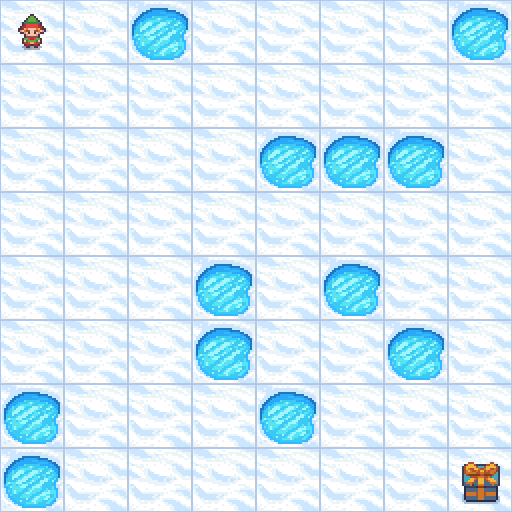

In [51]:
env = gym.make('FrozenLake-v1', desc=generate_random_map(size=8),render_mode="rgb_array", is_slippery=False)
env.reset()
rgb_matrix = env.render()
image = Image.fromarray(rgb_matrix)
actions = {
    "L":0,
    "D":1,
    "R":2,
    "U":3,
}
image

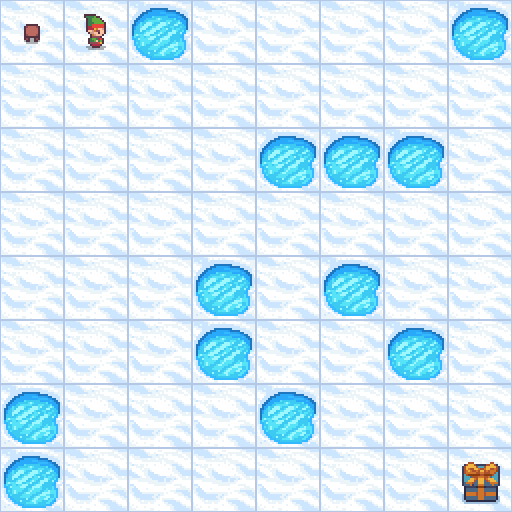

In [54]:
obs, reward, terminated, truncated, info = env.step(actions["R"])
rgb_matrix = env.render()
image = Image.fromarray(rgb_matrix)
image

In [39]:
# 获取文字描述（即地图）
text_map = env.unwrapped.desc  # byte数组
# text_map =  # 转换为字符串
text_map= [[i.decode('utf-8')  for i in line]for line in text_map]  # 转换为字符串列表
text_map

[['S', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'H', 'F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'H', 'F', 'F', 'H', 'H'],
 ['H', 'F', 'H', 'F', 'F', 'F', 'F', 'F'],
 ['H', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'H', 'H', 'F', 'F', 'F', 'H', 'H'],
 ['H', 'F', 'F', 'H', 'F', 'F', 'F', 'G']]

In [40]:
locs = extract_coordinates(text_map, cell_size=64)
locs

{'start': (32.0, 32.0),
 'holes': [(160.0, 96.0),
  (224.0, 160.0),
  (480.0, 160.0),
  (224.0, 224.0),
  (416.0, 224.0),
  (480.0, 224.0),
  (32.0, 288.0),
  (160.0, 288.0),
  (32.0, 352.0),
  (96.0, 416.0),
  (160.0, 416.0),
  (416.0, 416.0),
  (480.0, 416.0),
  (32.0, 480.0),
  (224.0, 480.0)],
 'goal': (480.0, 480.0)}

In [41]:
path = find_shortest_safe_path(locs)
path

'dddrddrrdrdrrr'

In [42]:
def verify_path(text_map, path_string, verbose=True):
    """
    Verify if a given sequence of actions leads to safely reaching the goal in the FrozenLake environment.
    
    Args:
        text_map (list): 2D list representing the FrozenLake map
        path_string (str): String of actions (r, l, u, d)
        verbose (bool): Whether to print detailed information during verification
    
    Returns:
        bool: True if the path leads to the goal, False otherwise
    """
    # Create environment
    env = gym.make('FrozenLake-v1', desc=text_map, render_mode="rgb_array" if verbose else None, is_slippery=False)
    obs, _ = env.reset()
    
    # Dictionary to map directions to actions expected by FrozenLake
    direction_to_action = {
        'l': 0,  # LEFT
        'd': 1,  # DOWN
        'r': 2,  # RIGHT
        'u': 3,  # UP
    }
    
    # Follow the path
    success = True
    step_count = 0
    
    for direction in path_string:
        action = direction_to_action.get(direction.lower())
        if action is None:
            if verbose:
                print(f"Invalid direction: {direction}")
            success = False
            break
            
        obs, reward, terminated, truncated, info = env.step(action)
        step_count += 1
        
        if verbose:
            print(f"Step {step_count}: Action {direction} -> Position {obs}, Reward {reward}")
            # Render the current state
            rgb_matrix = env.render()
            image = Image.fromarray(rgb_matrix)
            display(image)
        
        if terminated:
            # Check if we reached the goal or fell into a hole
            if reward == 1:
                if verbose:
                    print("Success! Reached the goal.")
            else:
                if verbose:
                    print("Failed! Fell into a hole.")
                success = False
            break
    
    # Check if we reached the goal
    if not terminated and verbose:
        print("Path completed but did not reach the goal.")
        success = False
    
    env.close()
    return success and reward == 1

In [44]:
verify_path(text_map, path, verbose=False)

True

ALSA lib confmisc.c:767:(parse_card) cannot find card '0'
ALSA lib conf.c:4555:(_snd_config_evaluate) function snd_func_card_driver returned error: No such file or directory
ALSA lib confmisc.c:392:(snd_func_concat) error evaluating strings
ALSA lib conf.c:4555:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1246:(snd_func_refer) error evaluating name
ALSA lib conf.c:4555:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5034:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2565:(snd_pcm_open_noupdate) Unknown PCM default


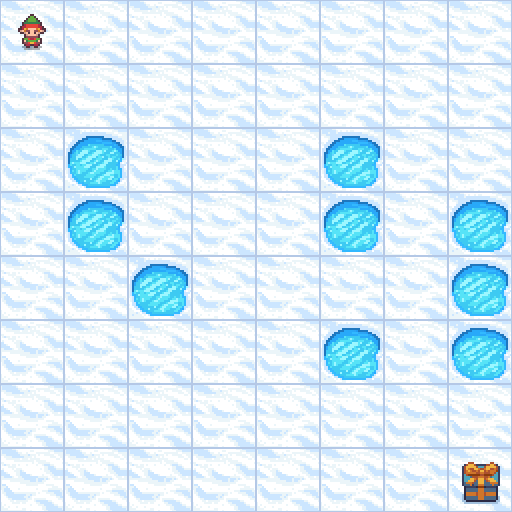

In [12]:
env = gym.make('FrozenLake-v1', desc=text_map,render_mode="rgb_array")
env.reset()
rgb_matrix = env.render()
image = Image.fromarray(rgb_matrix)
image

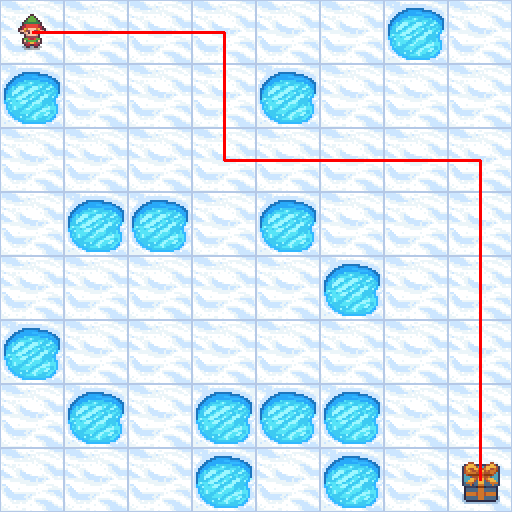

In [82]:
edited_image = draw_route(image, "[1, 1]", "rrrddrrrrddddd", pixel_coordinate=False, step=64)
edited_image

In [ ]:
actions = {
    "L":0,
    "D":1,
    "R":2,
    "U":3,
}

(1, 0.0, False, False, {'prob': 1.0})


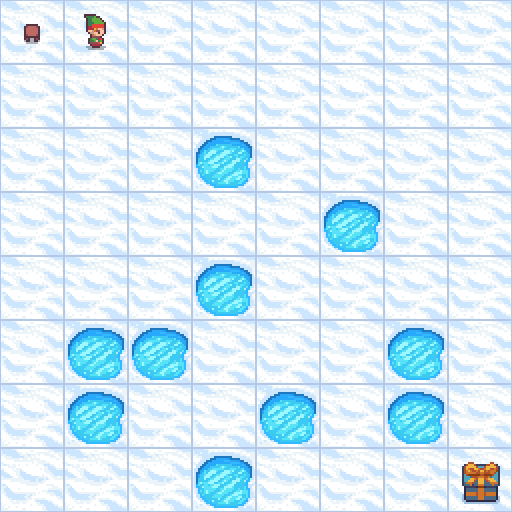

In [47]:
a=env.step(2)
rgb_matrix = env.render()
image = Image.fromarray(rgb_matrix)
print(a)
image

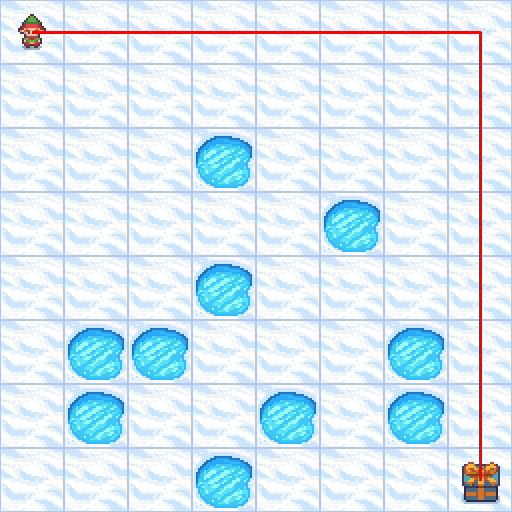

In [74]:
# edited_image = draw_direction_sequence(image, (32, 32), "rrrrrrrddddddd", step=64)
edited_image = draw_route(image, "[1, 1]", "rrrrrrrddddddd", pixel_coordinate=False, step=64)
edited_image